# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Membaca dataset mentah
# Membaca dataset menggunakan alamat lengkap di laptop
df = pd.read_csv("D:/New folder/Eksperimen_SML_Pradnya-Aliya/Crop_recommendation.csv")

# Menampilkan 5 data teratas untuk memastikan data berhasil terbaca
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Cek informasi umum dataset (jumlah baris, kolom, dan tipe data)
df.info()

# Cek apakah ada data yang kosong/null
print("\nJumlah data kosong per kolom:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Jumlah data kosong per kolom:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [4]:
# Menampilkan ringkasan statistik seperti rata-rata, min, max untuk data numerik
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Jumlah sampel per jenis tanaman:
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


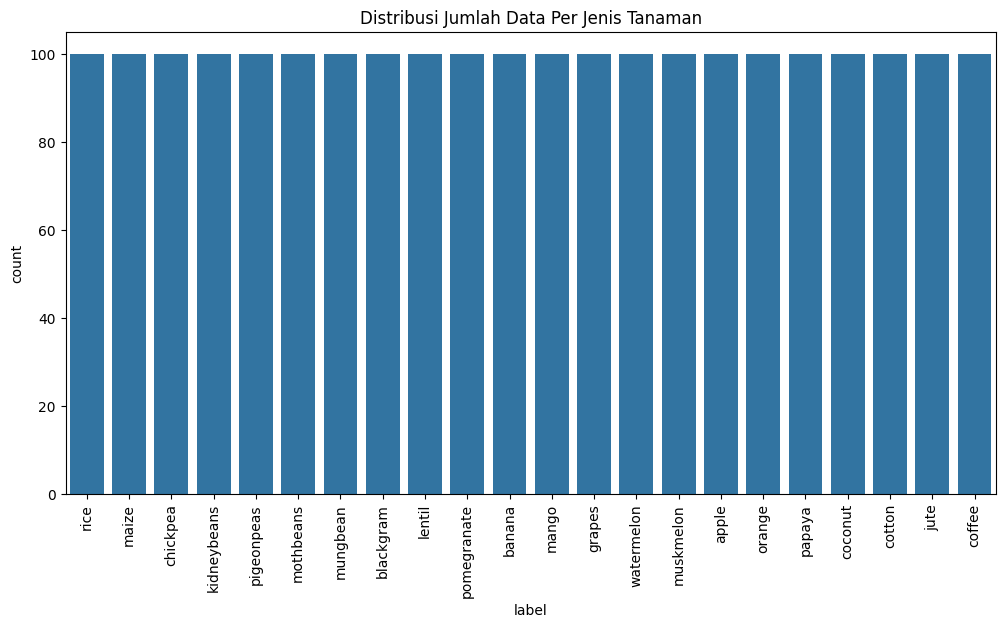

In [5]:
# Menghitung jumlah data untuk setiap jenis tanaman di kolom target
print("Jumlah sampel per jenis tanaman:")
print(df['label'].value_counts())

# Membuat grafik visualisasi sederhana untuk distribusi tanamannya
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label')
plt.xticks(rotation=90) # Memutar tulisan nama tanaman agar tidak tumpang tindih
plt.title("Distribusi Jumlah Data Per Jenis Tanaman")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# 1. Menghapus data duplikat jika ada
df = df.drop_duplicates()

# 2. Menangani missing value (jika ada, diisi dengan nilai rata-rata kelompoknya)
# Karena dataset ini biasanya lengkap, kode ini memastikan tidak ada yang terlewat
df = df.dropna()

print("Proses pembersihan duplikat dan data kosong selesai.")
print(f"Ukuran dataset sekarang: {df.shape}")

Proses pembersihan duplikat dan data kosong selesai.
Ukuran dataset sekarang: (2200, 8)


In [7]:
# Memisahkan Fitur (X) dan Target (y)
# X adalah semua kolom kecuali 'label'
X = df.drop(columns=['label'])

# y adalah hanya kolom 'label'
y = df['label']

print("Fitur (X) dan Target (y) berhasil dipisahkan.")

Fitur (X) dan Target (y) berhasil dipisahkan.


In [8]:
# 1. Mengubah nama tanaman jadi angka
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Skalasi angka X agar rentang nilainya sama (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Gabungin kembali Fitur yang sudah diskalasi dan Target jadi satu tabel baru
df_clean = pd.DataFrame(X_scaled, columns=X.columns)
df_clean['label'] = y_encoded

# 4. ALAMAT LENGKAP
folder_tujuan = "D:/New folder/Eksperimen_SML_Pradnya-Aliya/preprocessing"

# 5. Langsung simpan file CSV-nya di dalam folder preprocessing tersebut
df_clean.to_csv(f"{folder_tujuan}/crop_preprocessed.csv", index=False)

print("BERHASIL! File 'crop_preprocessed.csv' bersih tanpa import nyasar.")

BERHASIL! File 'crop_preprocessed.csv' bersih tanpa import nyasar.
